In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting

from dust_extinction.averages import CT06_MWGC

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from smart_plotters import cmd_plot 

from icemodels.colorcolordiagrams import plot_ccd_icemodels

from mpl_plot_templates import adaptive_param_plot 
import smart_plotters.co_ice as co_map
from icemodels.colorcolordiagrams import plot_ccd_icemodels

from astropy.modeling import models, fitting
#get_dmag_tbl

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [2]:
def get_rc_sel_mask(cat):
    x = np.linspace(0, 2.5, 10)
    
    x0 = 0.52
    mask_x0_left = cat.color('f182m', 'f212n') > x0

    y0 = 14.8
    mask_above_y0 = cat.band('f182m') > y0
    mask_rc = mask_above_y0 & mask_x0_left

    pt1 = (0.5, 14.3)
    pt2 = (2.0, 20.)
    y1 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_below_y1 = cat.band('f182m') > ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_below_y1 & mask_rc

    pt1 = (0.5, 15.5)
    pt2 = (2.0, 20.9)
    y2 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_above_y2 = cat.band('f182m') < ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_rc & mask_above_y2

    return mask_rc

In [3]:
cat_use = make_cat_use()
cat_brick = make_brick_cat()

Reading /orange/adamginsburg/jwst/brick/catalogs/basic_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits


In [4]:
cat_rc = JWSTCatalog(cat_use.catalog[get_rc_sel_mask(cat_use)])
cat_use_rc = cat_rc
cat_brick_rc = JWSTCatalog(cat_brick.catalog[get_rc_sel_mask(cat_brick)])

In [5]:
fn = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f405n-merged_i2d.fits'
hdu = fits.open(fn)
ww = WCS(hdu['SCI'].header)
nanfield = np.nan * hdu['SCI'].data

In [6]:
fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
hdu_brick = fits.open(fn_brick)
ww_brick = WCS(hdu_brick['SCI'].header)
nanfield_brick = np.nan * hdu_brick['SCI'].data

# Regions

In [7]:
reg_f = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_short.region')
reg_b = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudb.region')
reg_c1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc1_ice.reg')
reg_c2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc2_ice.reg')
reg_d = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudd_ice.reg')
reg_fil_r = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_right.region')
reg_left_cd = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/left_cloudd.region')
reg_c_n = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_north.region')
reg_c_s = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_south.region')

In [8]:
reg_brick_A = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_A.reg')
reg_brick_B = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_B.reg')
reg_brick_C = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_C.reg')
reg_brick_D = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_D.reg')

reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')



In [9]:
cat_f = JWSTCatalog(cat_use.table_region_mask(reg_f, ww_brick))

In [10]:
cat_f_rc = JWSTCatalog(cat_rc.table_region_mask(reg_f, ww))
cat_c1_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c1, ww))
cat_c2_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c2, ww))
cat_d_rc = JWSTCatalog(cat_rc.table_region_mask(reg_d, ww))
cat_b_rc = JWSTCatalog(cat_rc.table_region_mask(reg_b, ww))
cat_fil_r_rc = JWSTCatalog(cat_rc.table_region_mask(reg_fil_r, ww))
cat_left_cd_rc = JWSTCatalog(cat_rc.table_region_mask(reg_left_cd, ww))
cat_c_n_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_n, ww))
cat_c_s_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_s, ww))

In [11]:
cat_brick_A_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_A, ww_brick))
cat_brick_B_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_B, ww_brick))
cat_brick_C_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_C, ww_brick))
cat_brick_D_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_D, ww_brick))

cat_brick_north_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_punch_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nclear, ww_brick))
cat_brick_topc_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_topc, ww_brick))
cat_brick_sfrwide_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfrwide, ww_brick))

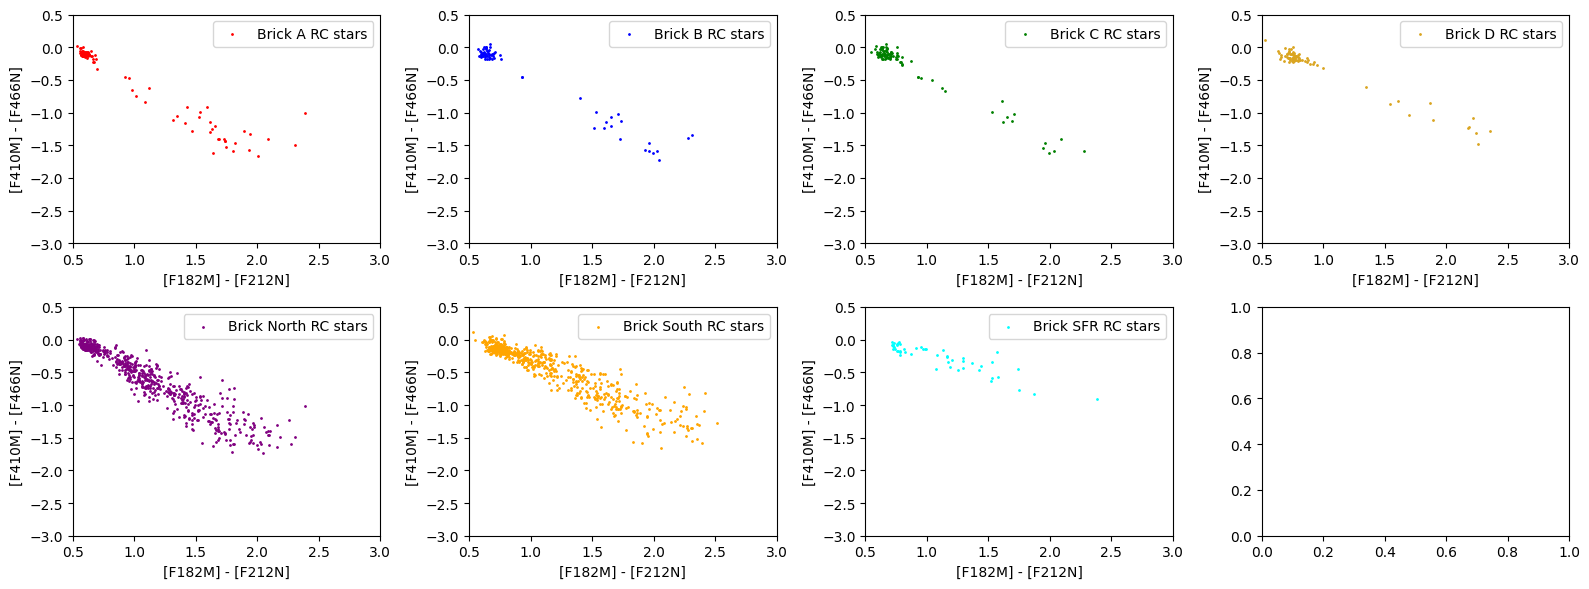

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

cat_alpha_rc = [cat_brick_A_rc, cat_brick_B_rc, cat_brick_C_rc, cat_brick_D_rc, cat_brick_north_rc, cat_brick_south_rc, cat_brick_sfr_rc]
colors = ['red', 'blue', 'green', 'goldenrod', 'purple', 'orange', 'cyan']
labels = ['A', 'B', 'C', 'D', 'North', 'South', 'SFR']

for i in range(len(cat_alpha_rc)):
    ax = axes.flatten()[i]
    cat = cat_alpha_rc[i]
    cat.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', ax=ax, color=colors[i], label=f'Brick {labels[i]} RC stars', s=1)
    ax.legend()
    ax.set_xlim(0.5, 3)
    ax.set_ylim(-3, 0.5)

    

plt.tight_layout()

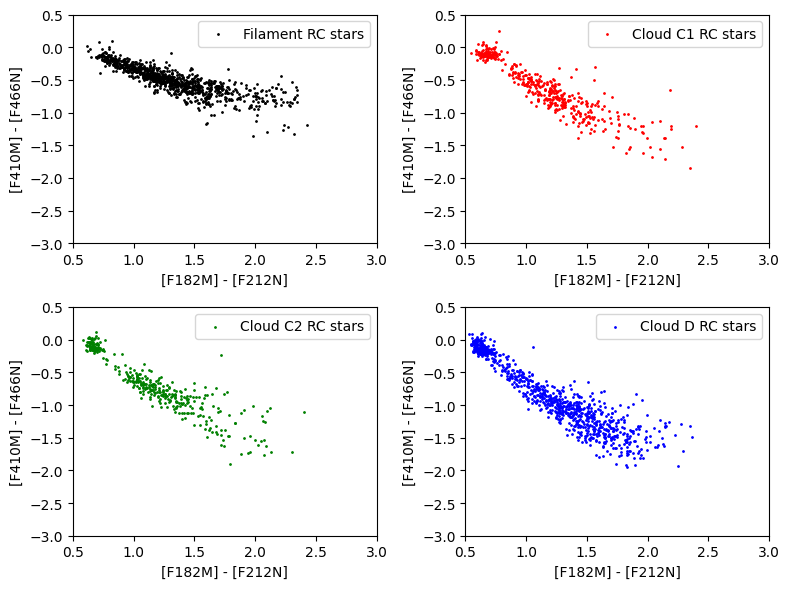

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

cat_alpha_rc = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc]
colors = ['k', 'red', 'green', 'blue']
labels = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D']

for i in range(4):
    ax = axes.flatten()[i]
    cat = cat_alpha_rc[i]
    cat.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', ax=ax, color=colors[i], label=f'{labels[i]} RC stars', s=1)
    ax.legend()
    ax.set_xlim(0.5, 3)
    ax.set_ylim(-3, 0.5)

    

plt.tight_layout()

# Model the CCDs for different ice compositions

In [14]:
mixes2 = [
    #('H2O:CO:CO2 (1:1:1)', 25.0),
    ##('H2O:CO:CO2 (3:1:0.5)', 25.0),
    #('H2O:CO:CO2 (2:1:1)', 25.0),
    #('H2O:CO:CO2 (3:1:1)', 25.0),
    #('H2O:CO:CO2 (5:1:1)', 25.0),
    ('H2O:CO:CO2 (10:1:1)', 25.0),
    ('H2O:CO:CO2 (10:1:0.5)', 25.0),
    ('H2O:CO:CO2 (15:1:1)', 25.0),
    ('H2O:CO:CO2 (20:1:1)', 25.0),
    # ('H2O:CO (1:1)', 25.0),
    # ('H2O:CO (3:1)', 25.0),
    # ('H2O:CO (5:1)', 25.0),
    # ('H2O:CO (10:1)', 25.0),
    # ('H2O:CO (15:1)', 25.0),
    # ('H2O:CO (20:1)', 25.0),
    #('H2O:CO:CO2:CH3OH (1:1:1:1)', 25.0),
    #('H2O:CO:CO2:CH3OH:CH3CH2OH (1:1:1:1:1)', 25.0),
]

In [15]:
tbl = co_map.get_dmag_tbl()
dmag_tbl = tbl
dmag_tbl.add_index('temperature')
tbl.add_index('database')
tbl.add_index('column')

`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]


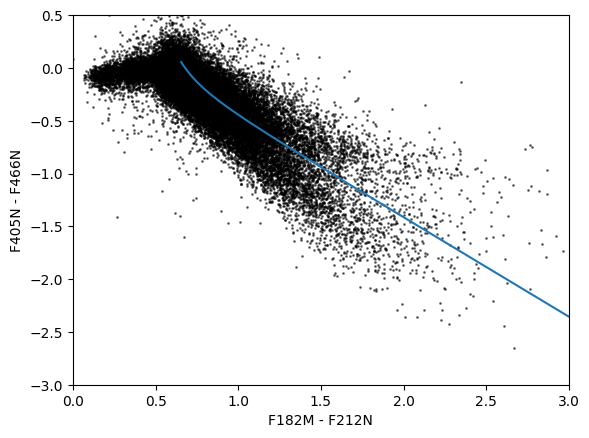

In [16]:
single_plot = [{
        'color1': ['F182M', 'F212N'],
        'color2': ['F405N', 'F466N'],
        'axlims': (0, 3, -3, 0.5),
        'molcomps': [('H2O:CO:CO2 (20:1:1)', 25.0)],
        'abundance_wrt_h2': 1.6e-4,#2.5e-4, #(percent_ice/100.)*carbon_abundance,
        'max_column': 5e22,
        'avstart': 17.0,
    }]

ax = plt.subplot(111)
cat_use.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, color='k')

ax.set_xlim(0, 3)
ax.set_ylim(-3, 0.5)

plot_params = single_plot[0]
a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_icemodels(
            color1=plot_params['color1'],
            color2=plot_params['color2'],
            dmag_tbl=dmag_tbl,
            molcomps=plot_params['molcomps'],
            axlims=plot_params['axlims'],
            #icemol=plot_params['icemol'],
            abundance_wrt_h2=plot_params['abundance_wrt_h2'],
            max_column=plot_params['max_column'], 
            color='tab:blue',
        )

(-6.0, 0.5)

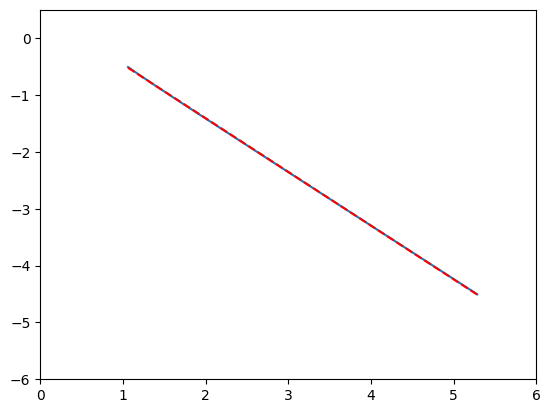

In [17]:
sel = (c1 > 1) & (c1 < 6)
plt.plot(c1[sel], c2[sel])

fit = fitting.LinearLSQFitter()
line_init = models.Linear1D()
fitted_line = fit(line_init, c1[sel], c2[sel])

plt.plot(c1[sel], fitted_line(c1[sel]), color='red', linestyle='--', label='Fitted Line')

plt.xlim(0, 6)
plt.ylim(-6, 0.5)

`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index

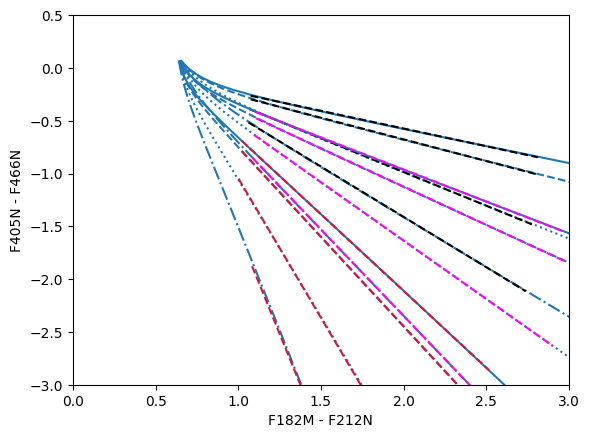

In [18]:
slopes_ = []
intercepts_ = []
abundances = [1.6e-4, 2.5e-4, 5e-4]

for i in range(len(abundances)):
    for mix in mixes2:
        plot_params['molcomps'] = [mix]
        a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_icemodels(
                    color1=plot_params['color1'],
                    color2=plot_params['color2'],
                    dmag_tbl=dmag_tbl,
                    molcomps=plot_params['molcomps'],
                    axlims=plot_params['axlims'],
                    #icemol=plot_params['icemol'],
                    abundance_wrt_h2=abundances[i],
                    max_column=plot_params['max_column'], 
                    color='tab:blue',
                )
        
        sel = (c1 > 1) & (c1 < 3)
        fit = fitting.LinearLSQFitter()
        line_init = models.Linear1D()
        fitted_line = fit(line_init, c1[sel], c2[sel])
        
        slopes_.append(fitted_line.slope.value)
        intercepts_.append(fitted_line.intercept.value)
        if i == 0:
            color = 'k'
        elif i == 1:
            color = 'magenta'
        elif i == 2:
            color = 'crimson'
        
        plt.plot(c1[sel], fitted_line(c1[sel]), linestyle='--', label=f'{mix[0]} slope={fitted_line.slope.value:.2f}', color=color)



(-0.1, 0.75)

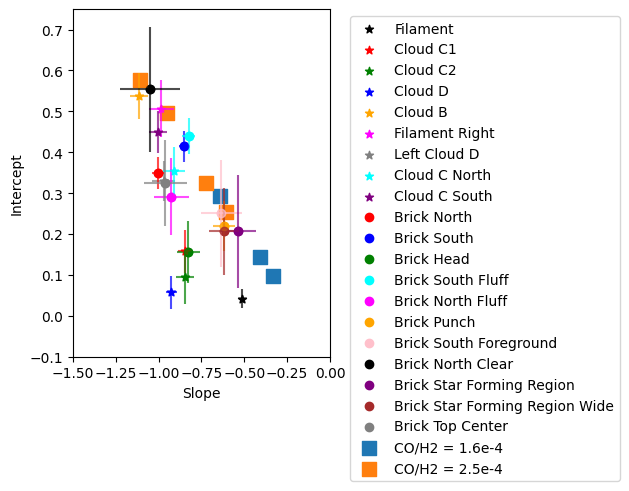

In [ ]:
catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']
color_list = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'grey', 'cyan', 'purple', 'r', 'b', 'g', 'cyan', 'magenta', 'orange', 'pink', 'k', 'purple', 'brown', 'gray']
cutoffs = [0.75, 0.8, 0.8, 0.75, 0.75, 0.7, 0.6, 0.7, 0.8, 0.8, 0.9, 0.75, 0.9, 0.7, 0.75, 1, 0.8, 1, 1, 0.7]
rang = np.linspace(0.5, 2.7, 100)

ax = plt.subplot(111)

for i in range(len(catalog_list)):
    cat = catalog_list[i]
    cat = JWSTCatalog(cat.catalog[cat.color('f182m', 'f212n') > cutoffs[i]])
    #cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=name_list[i], color=color_list[i])
    #ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []
    intercepts = []

    for j in range(1000):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]
        
        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)
        intercepts.append(line_boot.intercept.value)

    marker = 'o' if 'Brick' in name_list[i] else '*'

    ax.errorbar(np.mean(slopes), np.median(intercepts), xerr=np.std(slopes), yerr=np.std(intercepts), fmt=marker, color=color_list[i], alpha=0.7)#, linestyle=linestyle)
    ax.scatter(np.mean(slopes), np.median(intercepts), label=name_list[i], color=color_list[i], marker=marker)

for j in range(len(slopes_)):
    if j < 3:
        color='tab:blue' # CO/H2 = 1.6e-4
        if j == 0:
            label = 'CO/H2 = 1.6e-4'
        else:
            label = None
    if j >= 3 and j < 7:
        color='tab:orange' # CO/H2 = 2.5e-4
        if j == 3:
            label = 'CO/H2 = 2.5e-4'
        else:
            label = None
    if j >=7 and j < 10:
        color='tab:green' # CO/H2 = 5e-4
        if j == 7:
            label = None#'CO/H2 = 5e-4'
        else:
            label = None
    if i%4 == 0:
        textt = mixes2[0]
    elif i%4 == 1:
        textt = mixes2[1]
    elif i%4 == 2:
        textt = mixes2[2]
    elif i%4 == 3:
        textt = mixes2[3]
    ax.scatter(slopes_[j], intercepts_[j], color=color, s=100, marker='s', label=label)
    ax.text(textt, slopes_[j], intercepts_[j])
    

ax.set_xlabel('Slope')
ax.set_ylabel('Intercept')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax.set_xlim(-1.5, 0)
ax.set_ylim(-0.1, 0.75)

In [ ]:
i = 3
i%4

In [ ]:
print('hello')

In [ ]:
ax = plt.subplot(111)

for j in range(len(slopes_)):
    if j < 3:
        color='tab:blue' # CO/H2 = 1.6e-4
        if j == 0:
            label = 'CO/H2 = 1.6e-4'
        else:
            label = None
    if j >= 3 and j < 7:
        color='tab:orange' # CO/H2 = 2.5e-4
        if j == 3:
            label = 'CO/H2 = 2.5e-4'
        else:
            label = None
    if j >=7 and j < 10:
        color='tab:green' # CO/H2 = 5e-4
        if j == 7:
            label = 'CO/H2 = 5e-4'
        else:
            label = None
    if i%4 == 0:
        textt = mixes2[0]
    elif i%4 == 1:
        textt = mixes2[1]
    elif i%4 == 2:
        textt = mixes2[2]
    elif i%4 == 3:
        textt = mixes2[3]
    ax.scatter(slopes_[j], intercepts_[j], color=color, s=100, marker='s', label=label)
    ax.text(textt, slopes_[j], intercepts_[j])

ax.set_xlabel('Slope')
ax.set_ylabel('Intercept')

In [21]:
carbon_abundance = 10**(8.7-12) # = 1e-3.3 = 5e-4
oxygen_abundance = 10**(9.3-12)
percent_ice = 25  # can be changed per plot if needed

example_plots = [{
        'color1': ['F182M', 'F212N'],
        'color2': ['F405N', 'F466N'],
        'axlims': (0, 3, -3, 0.5),
        'molcomps': mixes2,
        'abundance_wrt_h2': 1.6e-4,#2.5e-4, #(percent_ice/100.)*carbon_abundance,
        'max_column': 5e22,
        'avstart': 17.0,
    },
    {
        # This one is totally pointless - it's just a vertical line
        'color1': ['F182M', 'F212N'],
        'color2': ['F405N', 'F466N'],
        'axlims': (0, 3, -3, 0.5),
        'molcomps': [
            ('H2O:CO:CO2 (1:1:1)', 25.0),
            ('H2O:CO:CO2 (3:1:1)', 25.0),
            ('H2O:CO:CO2 (5:1:1)', 25.0),
            ('H2O:CO:CO2 (10:1:1)', 25.0),
            ('H2O:CO:CO2 (15:1:1)', 25.0),
            ('H2O:CO:CO2 (20:1:1)', 25.0),
            ('H2O:CO2:CO 72:25:2.7', -999),
        ],
        'icemol': 'CO',
        'abundance_wrt_h2': (percent_ice/100.)*carbon_abundance,
        'max_column': 2e20,
        'pure_ice_no_dust': True,
        'column_to_plot_point': 1e19,
        #'title': f"{percent_ice}% of C in ice, $N_{{max}}$ = 2e20 cm$^{{-2}}$",
        #'filename': 'CCD_icemodel_F182M-F212N_F405N-F466N_H2OCOCO2_pureicenodust_nodata.png',
    },
    {
        'color1': ['F182M', 'F212N'],
        'color2': ['F405N', 'F466N'],
        'axlims': (0, 3, -3, 0.5),
        'molcomps': [
            ('H2O:CO:CO2 (1:1:1)', 25.0),
            ('H2O:CO:CO2 (3:1:1)', 25.0),
            ('H2O:CO:CO2 (5:1:1)', 25.0),
            ('H2O:CO:CO2 (10:1:1)', 25.0),
            ('H2O:CO:CO2 (15:1:1)', 25.0),
            ('H2O:CO:CO2 (20:1:1)', 25.0),
            ('H2O:CO2:CO 72:25:2.7', -999),
        ],
        'icemol': 'CO',
        'abundance_wrt_h2': (percent_ice/100.)*carbon_abundance,
        'max_column': 5e19,
        'title': f"{percent_ice}% of C in ice, $N_{{max}}$ = 5e19 cm$^{{-2}}$",
        'filename': 'CCD_icemodel_F182M-F212N_F405N-F466N_H2OCOCO2_nodata.png',
    }]

`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]


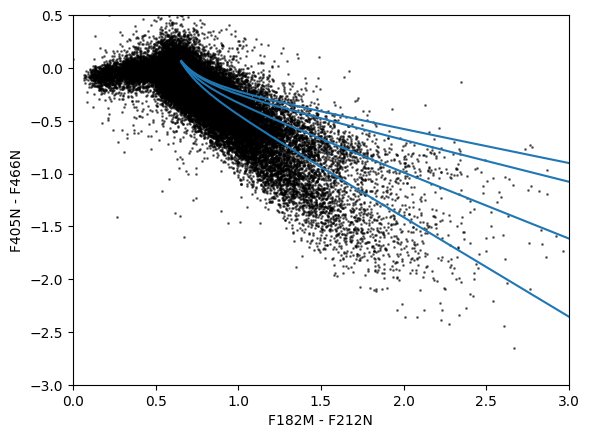

In [22]:
ax = plt.subplot(111)
cat_use.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, color='k')

ax.set_xlim(0, 3)
ax.set_ylim(-3, 0.5)

plot_params = example_plots[0]

a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_icemodels(
            color1=plot_params['color1'],
            color2=plot_params['color2'],
            dmag_tbl=dmag_tbl,
            molcomps=plot_params['molcomps'],
            axlims=plot_params['axlims'],
            #icemol=plot_params['icemol'],
            abundance_wrt_h2=plot_params['abundance_wrt_h2'],
            max_column=plot_params['max_column'], 
            color='tab:blue',
        )

`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]


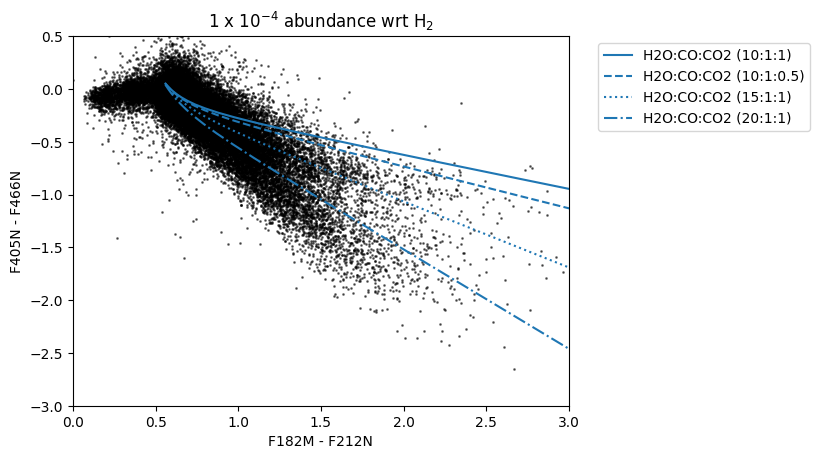

In [23]:
#ax = plt.subplot(111)
#cat_use.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', s=1, alpha=0.5, color='k')
#

#

plot_params = example_plots[0]

_ = plot_ccd_icemodels(
            color1=plot_params['color1'],
            color2=plot_params['color2'],
            dmag_tbl=dmag_tbl,
            molcomps=plot_params['molcomps'],
            axlims=plot_params['axlims'],
            #icemol=plot_params['icemol'],
            abundance_wrt_h2=1.6e-4, #plot_params['abundance_wrt_h2'],
            max_column=plot_params['max_column'], 
            av_start=plot_params['avstart'],
            #linestyle='-',
            #color='tab:blue',
        )

plt.scatter(cat_use.color('f182m', 'f212n'), cat_use.color('f405n', 'f466n'), s=1, alpha=0.5, color='k')

plt.xlim(0, 3)
plt.ylim(-3, 0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
plt.title(f"1 x 10$^{{-4}}$ abundance wrt H$_2$")
plt.show()


`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]


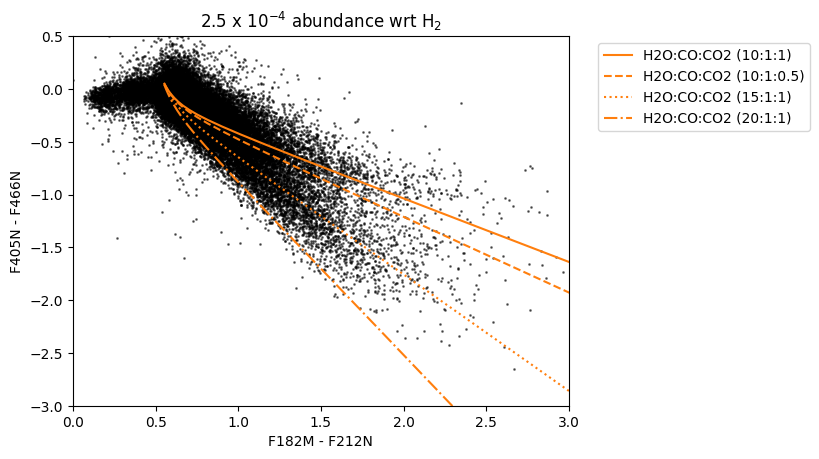

In [24]:
plot_params = example_plots[0]


_ = plot_ccd_icemodels(
            color1=plot_params['color1'],
            color2=plot_params['color2'],
            dmag_tbl=dmag_tbl,
            molcomps=plot_params['molcomps'],
            axlims=plot_params['axlims'],
            #icemol=plot_params['icemol'],
            abundance_wrt_h2= 2.5e-4, #plot_params['abundance_wrt_h2'],
            max_column=plot_params['max_column'], 
            av_start=plot_params['avstart'],
            #linestyle='--',
            color='tab:orange',
        )

plt.scatter(cat_use.color('f182m', 'f212n'), cat_use.color('f405n', 'f466n'), s=1, alpha=0.5, color='k')

plt.xlim(0, 3)
plt.ylim(-3, 0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
plt.title(f"2.5 x 10$^{{-4}}$ abundance wrt H$_2$")
plt.show()


`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]


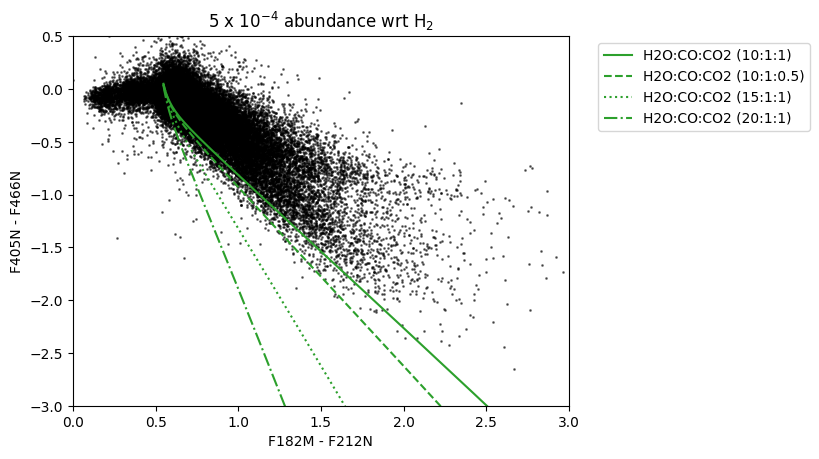

In [25]:
plot_params = example_plots[0]

_ = plot_ccd_icemodels(
            color1=plot_params['color1'],
            color2=plot_params['color2'],
            dmag_tbl=dmag_tbl,
            molcomps=plot_params['molcomps'],
            axlims=plot_params['axlims'],
            #icemol=plot_params['icemol'],
            abundance_wrt_h2= 5e-4, #plot_params['abundance_wrt_h2'],
            max_column=plot_params['max_column'], 
            av_start=plot_params['avstart'],
            #linestyle=':',
            color='tab:green',
        )

plt.scatter(cat_use.color('f182m', 'f212n'), cat_use.color('f405n', 'f466n'), s=1, alpha=0.5, color='k')

plt.xlim(0, 3)
plt.ylim(-3, 0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
plt.title(f"5 x 10$^{{-4}}$ abundance wrt H$_2$")
plt.show()


In [26]:
import smart_plotters.co_ice as co_map
from icemodels.colorcolordiagrams import plot_ccd_icemodels

tbl = co_map.get_dmag_tbl()
dmag_tbl = tbl

carbon_abundance = 10**(8.7-12) # = 1e-3.3 = 5e-4
oxygen_abundance = 10**(9.3-12)
percent_ice = 25  # can be changed per plot if needed

#ax = plt.subplot(111)

plot_params = {
        'color1': ['F182M', 'F212N'],
        'color2': ['F410M', 'F466N'],
        'axlims': (0, 3, -1.5, 1.0),
        'molcomps': [
            ('H2O:CO (0.5:1)', 25.0),
            ('H2O:CO (1:1)', 25.0),
            ('H2O:CO (3:1)', 25.0),
            ('H2O:CO (5:1)', 25.0),
            ('H2O:CO (7:1)', 25.0),
            ('H2O:CO (10:1)', 25.0),
            ('H2O:CO (15:1)', 25.0),
            ('H2O:CO (20:1)', 25.0),
        ],
        'icemol': 'CO',
        'abundance_wrt_h2': (percent_ice/100.)*carbon_abundance,
        'max_column': 2e20,
    }

plot_ccd_icemodels(
            color1=plot_params['color1'],
            color2=plot_params['color2'],
            dmag_tbl=dmag_tbl,
            molcomps=plot_params['molcomps'],
            axlims=plot_params['axlims'],
            icemol=plot_params['icemol'],
            abundance_wrt_h2=plot_params['abundance_wrt_h2'],
            max_column=plot_params['max_column'],
        )

#plt.legend()

`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]


IndexError: No index found for ['temperature']

# Apply to lines of sight

In [ ]:
mixes2 = [
    #('H2O:CO:CO2 (1:1:1)', 25.0),
    ##('H2O:CO:CO2 (3:1:0.5)', 25.0),
    #('H2O:CO:CO2 (2:1:1)', 25.0),
    #('H2O:CO:CO2 (3:1:1)', 25.0),
    #('H2O:CO:CO2 (5:1:1)', 25.0),
    ('H2O:CO:CO2 (10:1:1)', 25.0),
    ('H2O:CO:CO2 (10:1:0.5)', 25.0),
    ('H2O:CO:CO2 (15:1:1)', 25.0),
    ('H2O:CO:CO2 (15:1:0.5)', 25.0),
    #('H2O:CO:CO2 (20:1:1)', 25.0),
    # ('H2O:CO (1:1)', 25.0),
    # ('H2O:CO (3:1)', 25.0),
    # ('H2O:CO (5:1)', 25.0),
    # ('H2O:CO (10:1)', 25.0),
    # ('H2O:CO (15:1)', 25.0),
    # ('H2O:CO (20:1)', 25.0),
    #('H2O:CO:CO2:CH3OH (1:1:1:1)', 25.0),
    #('H2O:CO:CO2:CH3OH:CH3CH2OH (1:1:1:1:1)', 25.0),
]

example_plots = [{
        'color1': ['F182M', 'F212N'],
        'color2': ['F405N', 'F466N'],
        'axlims': (0, 3, -3, 0.5),
        'molcomps': mixes2,
        #'abundance_wrt_h2': 1.6e-4,#2.5e-4, #(percent_ice/100.)*carbon_abundance,
        'max_column': 5e22,
        'avstart': 17.0,
    }]

In [ ]:
def plot_icemodel(plot_params, abundance=1.6e-4, av_start=plot_params['avstart'],**kwargs):
    _ = plot_ccd_icemodels(
                color1=plot_params['color1'],
                color2=plot_params['color2'],
                dmag_tbl=dmag_tbl,
                molcomps=plot_params['molcomps'],
                axlims=plot_params['axlims'],
                abundance_wrt_h2=abundance, 
                max_column=plot_params['max_column'], 
                av_start=av_start,
                **kwargs
            )

    #plt.scatter(cat_use.color('f182m', 'f212n'), cat_use.color('f405n', 'f466n'), s=1, alpha=0.5, color='k')

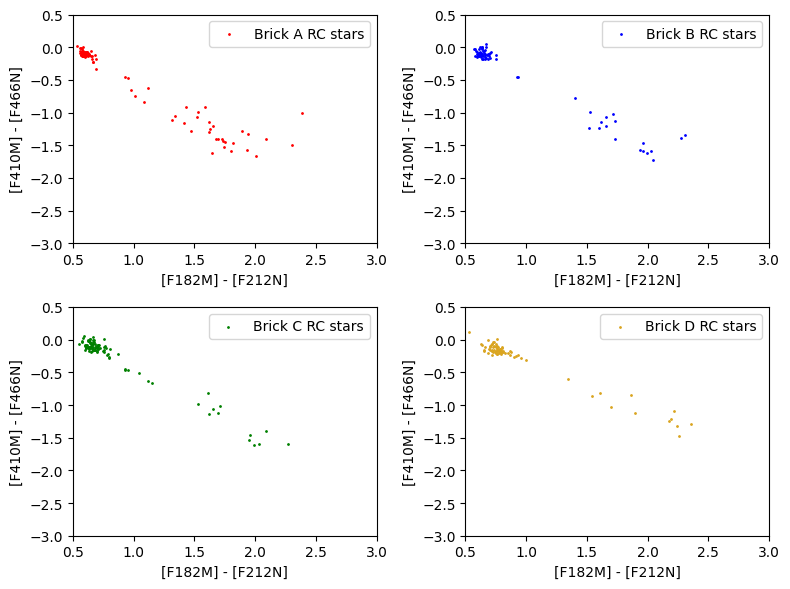

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

cat_alpha_rc = [cat_brick_A_rc, cat_brick_B_rc, cat_brick_C_rc, cat_brick_D_rc]
colors = ['red', 'blue', 'green', 'goldenrod']

for i in range(4):
    ax = axes.flatten()[i]
    cat = cat_alpha_rc[i]
    cat.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', ax=ax, color=colors[i], label=f'Brick {chr(65+i)} RC stars', s=1)
    ax.legend()
    ax.set_xlim(0.5, 3)
    ax.set_ylim(-3, 0.5)

    #plot_icemodel(plot_params=example_plots[0], abundance=1.6e-4, ax=ax)

plt.tight_layout()

Text(0.5, 1.0, 'Brick A, CO abundance = 3.0e-04')

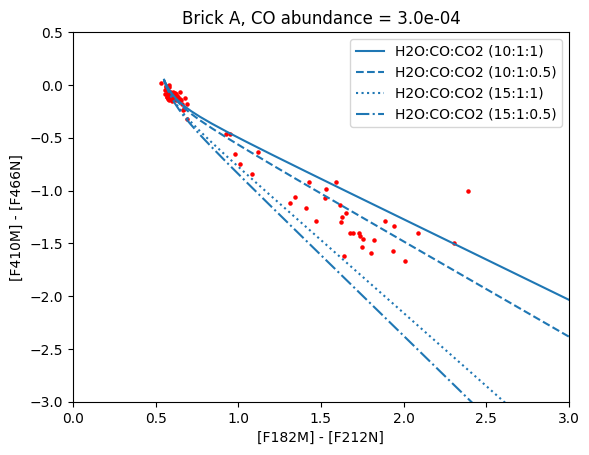

In [ ]:
abundance = 3e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue')
plt.legend()
cat_brick_A_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='red', label=f'Brick A RC stars', s=5)
plt.title(f'Brick A, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'Brick D, CO abundance = 3.0e-04')

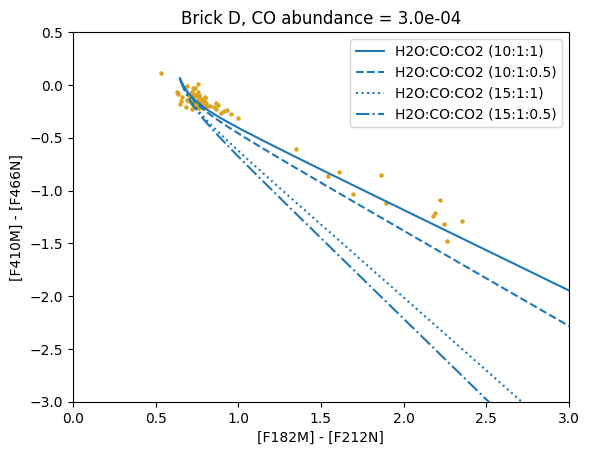

In [ ]:
abundance = 3e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue', av_start=20)
plt.legend()
cat_brick_D_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='goldenrod', label=f'Brick D RC stars', s=5)
plt.title(f'Brick D, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'CO abundance = 3.0e-04')

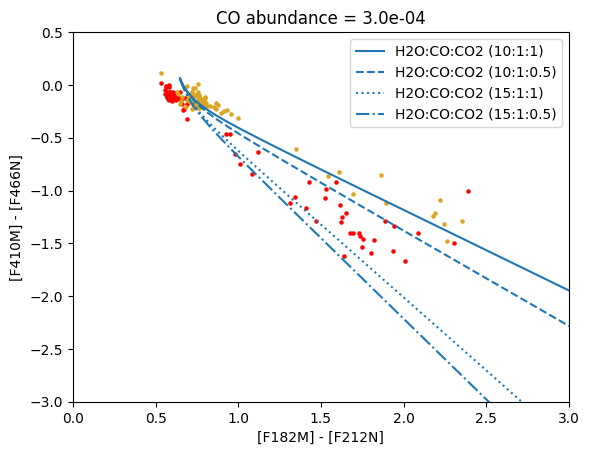

In [ ]:
abundance = 3e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue', av_start=20)
#plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:orange', av_start=17)

plt.legend()
cat_brick_A_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='red', label=f'Brick A RC stars', s=5)
cat_brick_D_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='goldenrod', label=f'Brick D RC stars', s=5)
plt.title(f'CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'Filament, CO abundance = 1.6e-04')

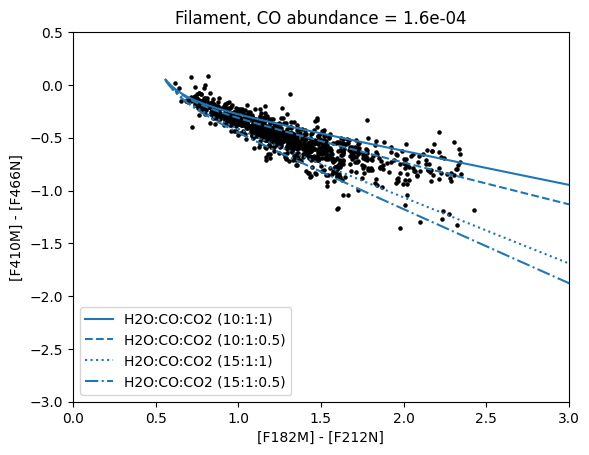

In [ ]:
abundance = 1.6e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue', av_start=17)
plt.legend()
cat_f_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='k', label=f'Filament RC stars', s=5)
plt.title(f'Filament, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'Cloud C1, CO abundance = 5.0e-04')

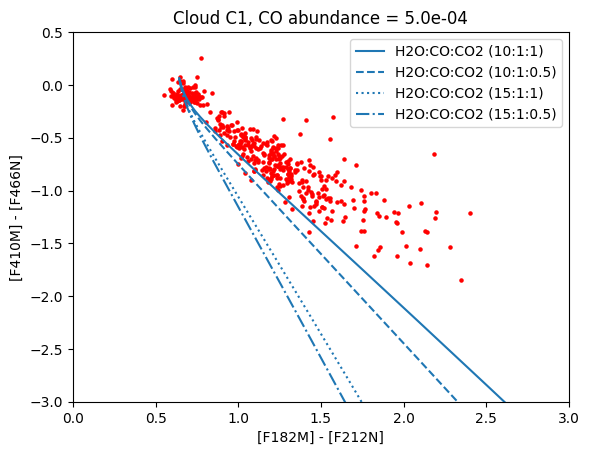

In [ ]:
abundance = 5e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue', av_start=20)
plt.legend()
cat_c1_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='r', label=f'Cloud C1 RC stars', s=5)
plt.title(f'Cloud C1, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'Cloud D, CO abundance = 5.0e-04')

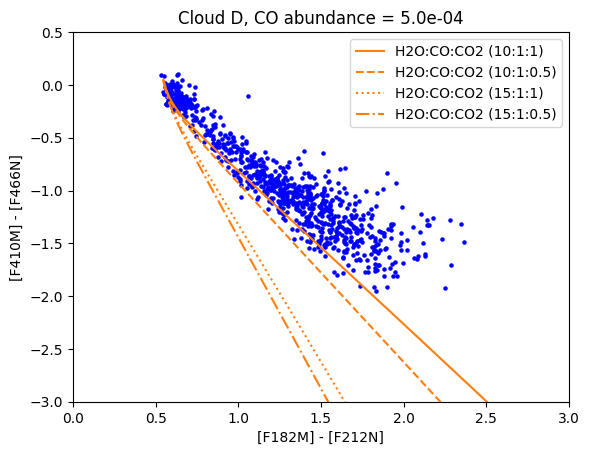

In [ ]:
abundance = 5e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:orange', av_start=17)
plt.legend()
cat_d_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='b', label=f'Cloud D RC stars', s=5)
plt.title(f'Cloud D, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'CO abundance = 4.0e-04')

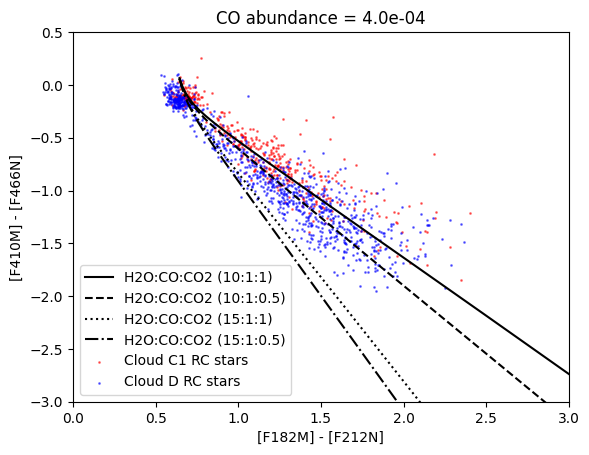

In [ ]:
abundance = 4e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='k', av_start=20)

cat_c1_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='r', label=f'Cloud C1 RC stars', s=1, alpha=0.5)
cat_d_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='b', label=f'Cloud D RC stars', s=1, alpha=0.5)
plt.legend()
plt.title(f'CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'Brick North, CO abundance = 3.0e-04')

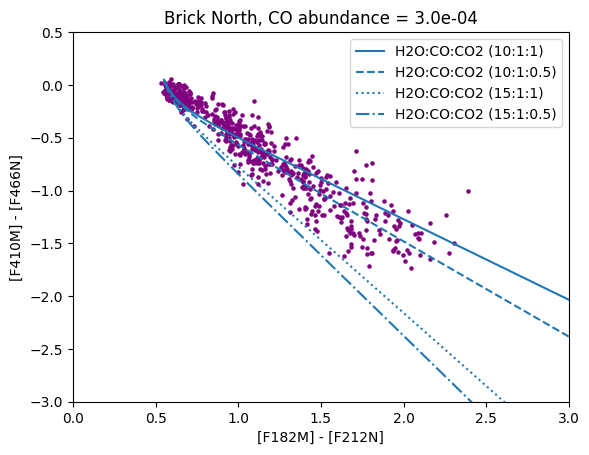

In [ ]:
abundance = 3e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue', av_start=17)
plt.legend()
cat_brick_north_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='purple', label=f'Brick North RC stars', s=5)
plt.title(f'Brick North, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'Brick South, CO abundance = 3.0e-04')

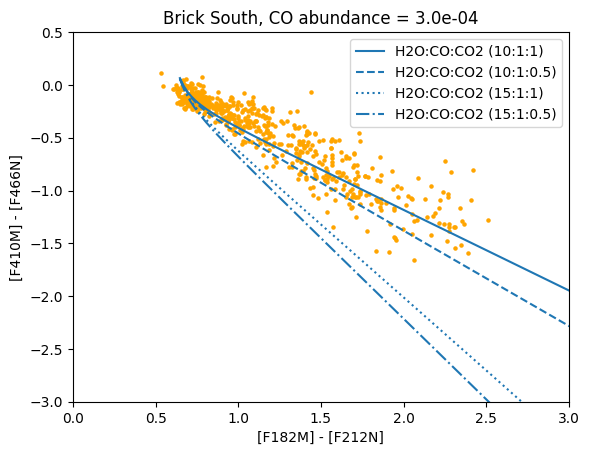

In [ ]:
abundance = 3e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue', av_start=20)
plt.legend()
cat_brick_south_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='orange', label=f'Brick South RC stars', s=5)
plt.title(f'Brick South, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'CO abundance = 3.0e-04')

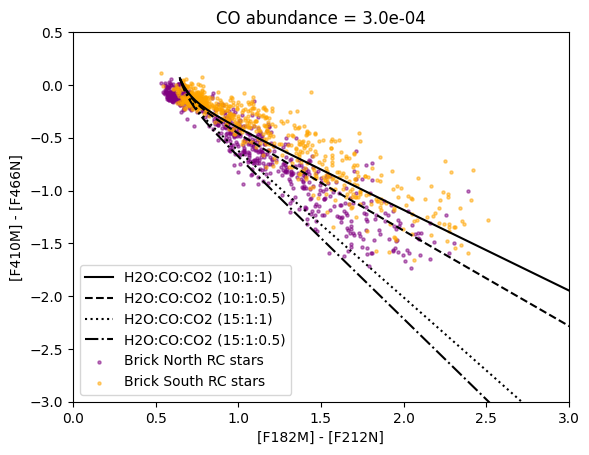

In [ ]:
abundance = 3e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='k', av_start=20)
cat_brick_north_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='purple', label=f'Brick North RC stars', s=5, alpha=0.5)
cat_brick_south_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='orange', label=f'Brick South RC stars', s=5, alpha=0.5)
plt.legend()
plt.title(f'CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'Brick SFR, CO abundance = 1.6e-04')

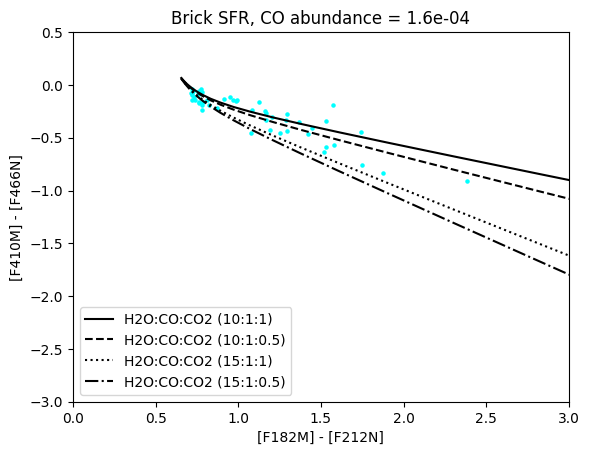

In [ ]:
abundance = 1.6e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='k', av_start=20)
plt.legend(loc='lower left')
cat_brick_sfr_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='cyan', label=f'Brick SFR RC stars', s=5)
plt.title(f'Brick SFR, CO abundance = {abundance:.1e}')

Text(0.5, 1.0, 'CO abundance = 1.6e-04')

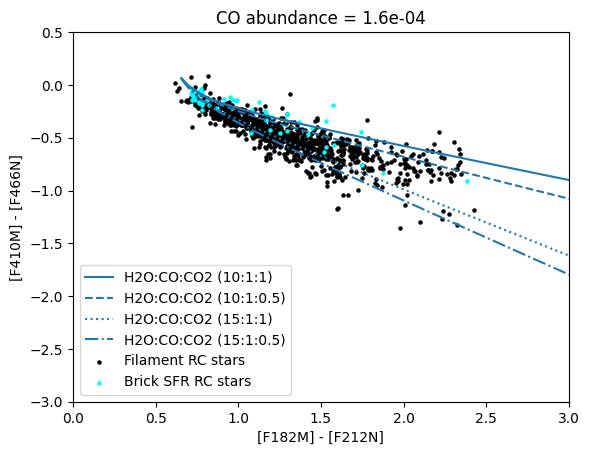

In [ ]:
abundance = 1.6e-4

plot_icemodel(plot_params=example_plots[0], abundance=abundance, color='tab:blue', av_start=20)
cat_f_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='k', label=f'Filament RC stars', s=5)
cat_brick_sfr_rc.plot_CCD('f182m', 'f212n', 'f410m', 'f466n', color='cyan', label=f'Brick SFR RC stars', s=5)
plt.legend(loc='lower left')

plt.title(f'CO abundance = {abundance:.1e}')